<a href="https://colab.research.google.com/github/Ayush2005292/ML/blob/main/lab5(_ML_Linear_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 class MyLinearRegression:
    def __init__(self, weight=1, bias=4, learning_rate=0.0008,
                 iterations=70):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        predicted_set = []
        for i in range(len(x)):
            predicted_value = self.weight * x[i] + self.bias
            predicted_set.append(predicted_value)
        return predicted_set

    def cost_function(self, x, y):
        count = len(x)
        total_error = 0.0
        for i in range(count):
            total_error += (y[i] - (self.weight * x[i] +
                            self.bias)) ** 2
        return float(total_error) / (2 * count)

    def update_weights(self, x, y):
        weight_deriv = 0
        bias_deriv = 0
        count = len(x)

        for i in range(count):
            # Calculate partial derivatives
            # -2x(y - (mx + b))
            weight_deriv += -2 * x[i] * (y[i] -(self.weight * x[i] + self.bias))

            # -2(y - (mx + b))
            bias_deriv += -2 * (y[i] - (self.weight * x[i] +
                                self.bias))

        # We subtract because the derivatives point in direction of steepest
        # ascent
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            # Calculating cost
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)
           # if i % 10000 == 0:
            print("Iteration: {}\t Weight: {}\t Bias: {}\t Cost: {}".format(i, self.weight, self.bias, self.cost))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Time':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25],
        'Study':[10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Time,Study
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60
6,7,70
7,8,80
8,9,90
9,10,100


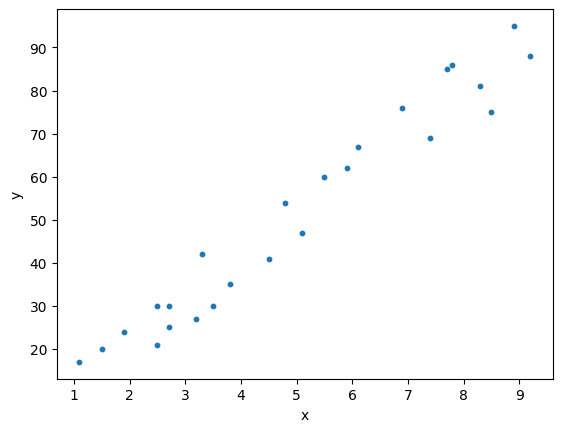

In [4]:
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [5]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11],
        [12],
        [13],
        [14],
        [15],
        [16],
        [17],
        [18],
        [19],
        [20],
        [21],
        [22],
        [23],
        [24],
        [25]]),
 array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
        140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250]))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train)
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)


Iteration: 0	 Weight: [3.2629]	 Bias: [4.1529]	 Cost: 3376.999324650937
Iteration: 1	 Weight: [4.9363237]	 Bias: [4.26550203]	 Cost: 1847.8644786998098
Iteration: 2	 Weight: [6.17383558]	 Bias: [4.3483043]	 Cost: 1011.6631969853461
Iteration: 3	 Weight: [7.08899503]	 Bias: [4.40907012]	 Cost: 554.3894546700662
Iteration: 4	 Weight: [7.76577808]	 Bias: [4.4535404]	 Cost: 304.33049851671996
Iteration: 5	 Weight: [8.26628416]	 Bias: [4.48596046]	 Cost: 167.5859976649171
Iteration: 6	 Weight: [8.63643517]	 Bias: [4.50946969]	 Cost: 92.80698723287577
Iteration: 7	 Weight: [8.91018992]	 Bias: [4.52638964]	 Cost: 51.91352149203182
Iteration: 8	 Weight: [9.11266058]	 Bias: [4.53843705]	 Cost: 29.55021102124981
Iteration: 9	 Weight: [9.26241735]	 Bias: [4.54688146]	 Cost: 17.320031603995744
Iteration: 10	 Weight: [9.37319273]	 Bias: [4.55266167]	 Cost: 10.631109093473631
Iteration: 11	 Weight: [9.45514174]	 Bias: [4.5564719]	 Cost: 6.972398190970949
Iteration: 12	 Weight: [9.51577394]	 Bias: [4

/tmp/ipykernel_4711/3551679376.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


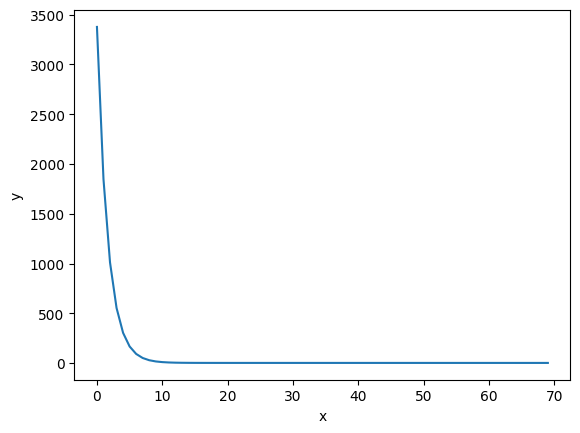

In [7]:
x=[int(x) for x in range(70)]
y=regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

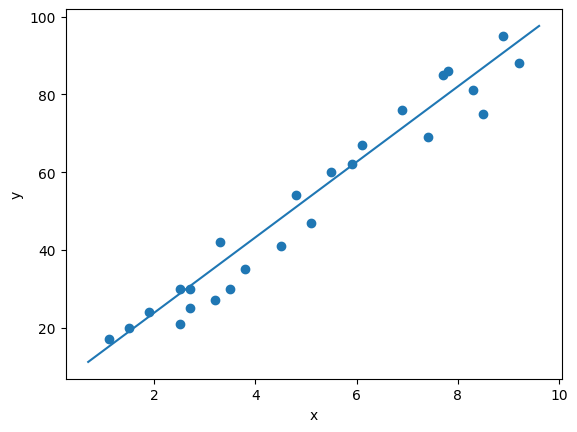

In [8]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [9]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)

# Simple comparison
print("COMPARISON OF PREDICTED VS ACTUAL VALUES:")
print("-" * 40)
for i in range(len(y_pred)):
    # Convert to float to avoid formatting issues
    pred_val = float(y_pred[i])
    actual_val = float(y_test[i])
    diff = abs(pred_val - actual_val)
    print(f"Predicted: {pred_val:.2f} | Actual: {actual_val:.2f} | Difference: {diff:.2f}")

# Calculate accuracy
errors = []
for i in range(len(y_pred)):
    error = abs(float(y_pred[i]) - float(y_test[i]))
    errors.append(error)

average_error = sum(errors) / len(errors)
print("-" * 40)
print(f"Average Error: {average_error:.2f}")
print(f"Best Prediction: {min(errors):.2f} off")
print(f"Worst Prediction: {max(errors):.2f} off")

COMPARISON OF PREDICTED VS ACTUAL VALUES:
----------------------------------------
Predicted: 62.64 | Actual: 60.00 | Difference: 2.64
Predicted: 33.55 | Actual: 30.00 | Difference: 3.55
Predicted: 198.36 | Actual: 200.00 | Difference: 1.64
Predicted: 169.28 | Actual: 170.00 | Difference: 0.72
Predicted: 120.80 | Actual: 120.00 | Difference: 0.80
Predicted: 227.44 | Actual: 230.00 | Difference: 2.56
Predicted: 178.97 | Actual: 180.00 | Difference: 1.03
Predicted: 246.83 | Actual: 250.00 | Difference: 3.17
Predicted: 237.14 | Actual: 240.00 | Difference: 2.86
----------------------------------------
Average Error: 2.11
Best Prediction: 0.72 off
Worst Prediction: 3.55 off


/tmp/ipykernel_4711/1108160880.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(y_pred[i])
/tmp/ipykernel_4711/1108160880.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error = abs(float(y_pred[i]) - float(y_test[i]))
